In [1]:
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 下載繁體中文字型
!wget -O SourceHanSerifTW-VF.ttf https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf

# 加入字型檔
fm.fontManager.addfont('SourceHanSerifTW-VF.ttf')

# 設定字型
#
mpl.rc('font', family='Source Han Serif TW VF')

--2026-06-23 06:41:20--  https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adobe-fonts/source-han-serif/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf [following]
--2026-06-23 06:41:20--  https://raw.githubusercontent.com/adobe-fonts/source-han-serif/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16851180 (16M) [application/octet-stream]
Saving to: ‘SourceHanSerifTW-VF.ttf’

SourceHanSerifTW-VF 100%[===================>]  16.07M  99.5

In [3]:
import numpy as np
import pandas as pd

# 1. 定義初始資金與 4 個情境的 6 年報酬率數據
initial_wealth = 100

data = {
    "情境備註": [
        "原始範例",
        "高波動、大暴漲大暴跌情境",
        "超低波動、穩定增長情境（類似高評級債券）",
        "中度波動、穩健成長情境（類似市值型 ETF）",
    ],
    "第1年": [0.25, 0.60, 0.04, 0.15],
    "第2年": [-0.15, -0.40, 0.035, -0.05],
    "第3年": [0.10, 0.30, 0.042, 0.20],
    "第4年": [-0.08, -0.20, 0.038, 0.10],
    "第5年": [0.45, 0.50, 0.045, -0.10],
    "第6年": [-0.30, -0.50, 0.034, 0.25],
}

# 建立 DataFrame
df = pd.DataFrame(data)

# 提取報酬率欄位進行數學計算
returns_cols = ["第1年", "第2年", "第3年", "第4年", "第5年", "第6年"]
returns_matrix = df[returns_cols].values

# 2. 開始計算財務指標

# (H欄) 算術平均報酬率
df["算術平均報酬率"] = returns_matrix.mean(axis=1)

# (I欄) 波動率（標準差）
# 註：Excel 的 STDEV.P 是母體標準差，故 Python 需設定 ddof=0 才會與 Excel 完全一致
df["波動率（標準差）"] = returns_matrix.std(axis=1, ddof=0)

# (J欄) 實際幾何複利
# 計算每一年的總資產倍數 (1 + R)，再求乘積後開 6 次根號
df["實際幾何複利"] = (np.prod(1 + returns_matrix, axis=1) ** (1 / 6)) - 1

# (K欄) 近似公式預估值
df["近似公式預估值"] = df["算術平均報酬率"] - (df["波動率（標準差）"] ** 2) / 2


# 3. 格式化輸出表格（轉換為百分比格式，方便對照 Excel）
output_df = df.copy()
output_df["初始資金"] = initial_wealth

# 調整欄位順序以符合您的 Excel 結構
cols_order = (
    ["初始資金"]
    + returns_cols
    + ["算術平均報酬率", "波動率（標準差）", "實際幾何複利", "近似公式預估值", "情境備註"]
)
output_df = output_df[cols_order]

# 將數值欄位轉為百分比顯示
pct_cols = [
    "第1年",
    "第2年",
    "第3年",
    "第4年",
    "第5年",
    "第6年",
    "算術平均報酬率",
    "波動率（標準差）",
    "實際幾何複利",
    "近似公式預估值",
]
for col in pct_cols:
    output_df[col] = output_df[col].apply(lambda x: f"{x*100:.2f}%")

# 顯示結果
print(output_df.to_string(index=False))

 初始資金    第1年     第2年    第3年     第4年     第5年     第6年 算術平均報酬率 波動率（標準差） 實際幾何複利 近似公式預估值                   情境備註
  100 25.00% -15.00% 10.00%  -8.00%  45.00% -30.00%   4.50%   25.22%  1.47%   1.32%                   原始範例
  100 60.00% -40.00% 30.00% -20.00%  50.00% -50.00%   5.00%   43.49% -4.71%  -4.46%           高波動、大暴漲大暴跌情境
  100  4.00%   3.50%  4.20%   3.80%   4.50%   3.40%   3.90%    0.38%  3.90%   3.90%   超低波動、穩定增長情境（類似高評級債券）
  100 15.00%  -5.00% 20.00%  10.00% -10.00%  25.00%   9.17%   12.72%  8.40%   8.36% 中度波動、穩健成長情境（類似市值型 ETF）


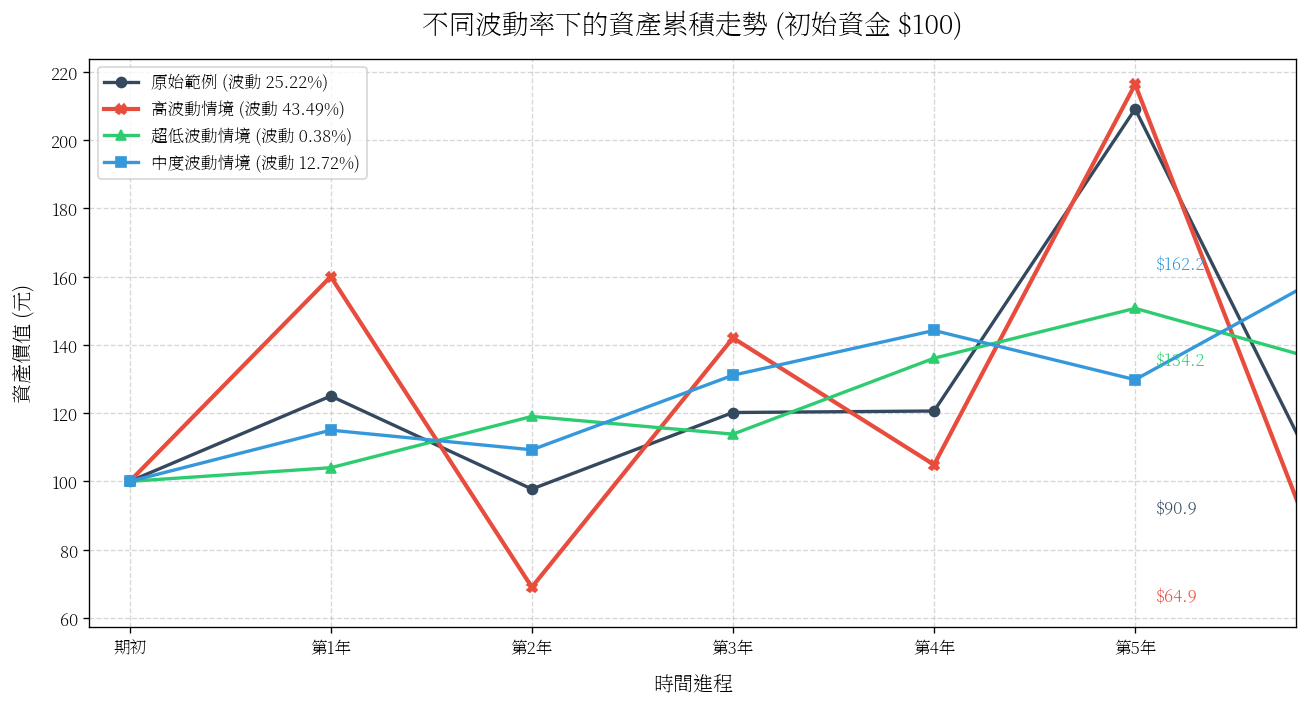

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------------------------------------------------
# 1. 中文字型支援設定 (解決 matplotlib 中文亂碼問題)
# -------------------------------------------------------------------------
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Arial Unicode MS",
    "SimHei",
]
plt.rcParams["axes.unicode_minus"] = False  # 正常顯示負號

# -------------------------------------------------------------------------
# 2. 定義資料與計算資產走勢
# -------------------------------------------------------------------------
initial_wealth = 100
scenarios = {
    "原始範例 (波動 25.22%)": [0.25, -0.15, 0.10, -0.08, 0.45, -0.30],
    "高波動情境 (波動 43.49%)": [0.60, -0.40, 0.30, -0.20, 0.50, -0.50],
    "超低波動情境 (波動 0.38%)": [0.04, 0.035, 0.042, 0.038, 0.045, 0.034],
    "中度波動情境 (波動 12.72%)": [0.15, -0.05, 0.20, 0.10, -0.10, 0.25],
}

# 建立一個 dictionary 來存放每一年份的資產價值
wealth_trends = {"期初": [initial_wealth] * len(scenarios)}

# 計算每年累積的資產
for year in range(1, 7):
    year_key = f"第{year}年"
    wealth_trends[year_key] = []
    for s_name, returns in scenarios.items():
        # 如果是第一年，用初始資金乘；之後用前一年的資金乘
        if year == 1:
            prev_wealth = initial_wealth
        else:
            prev_wealth = wealth_trends[f"第{year-1}年"][-1]

        current_return = returns[year - 1]
        next_wealth = prev_wealth * (1 + current_return)
        wealth_trends[year_key].append(next_wealth)

# 調整資料結構以便繪圖
df_trends = pd.DataFrame(wealth_trends, index=scenarios.keys()).T

# -------------------------------------------------------------------------
# 3. 開始繪製圖片
# -------------------------------------------------------------------------
plt.figure(figsize=(11, 6), dpi=120)  # 設定畫布大小與解析度

# 設定線條樣式與顏色，讓圖表更清晰、美觀
styles = {
    "原始範例 (波動 25.22%)": {"color": "#34495e", "marker": "o", "linewidth": 2},
    "高波動情境 (波動 43.49%)": {
        "color": "#e74c3c",
        "marker": "X",
        "linewidth": 2.5,
    },
    "超低波動情境 (波動 0.38%)": {
        "color": "#2ecc71",
        "marker": "^",
        "linewidth": 2,
    },
    "中度波動情境 (波動 12.72%)": {
        "color": "#3498db",
        "marker": "s",
        "linewidth": 2,
    },
}

# 畫出每一條情境線
for column in df_trends.columns:
    plt.plot(
        df_trends.index,
        df_trends[column],
        label=column,
        color=styles[column]["color"],
        marker=styles[column]["marker"],
        linewidth=styles[column]["linewidth"],
    )
    # 在第6年結尾加上最終資產價值的數字標籤
    final_val = df_trends[column].iloc[-1]
    plt.text(
        5.1,
        final_val,
        f"${final_val:.1f}",
        fontsize=10,
        fontweight="bold",
        color=styles[column]["color"],
    )

# -------------------------------------------------------------------------
# 4. 圖表細節優化
# -------------------------------------------------------------------------
plt.title("不同波動率下的資產累積走勢 (初始資金 $100)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("時間進程", fontsize=12, labelpad=10)
plt.ylabel("資產價值 (元)", fontsize=12, labelpad=10)
plt.grid(True, linestyle="--", alpha=0.5)  # 開啟網格線
plt.legend(loc="upper left", fontsize=10)  # 顯示圖例
plt.xlim(-0.2, 5.8)  # 稍微拉寬X軸邊界以容納文字標籤

# 自動調整版面並顯示圖片
plt.tight_layout()
plt.show()